# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Load the Dataset

In [7]:
df = pd.read_csv('bank.csv',sep=';')

In [8]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


# Check Basic Details

In [9]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [10]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [11]:
df.shape

(4521, 17)

In [12]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


# Data Cleaning

In [14]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
y            0.0
dtype: float64

In [16]:
df.duplicated().sum()

np.int64(0)

"The dataset was checked for duplicate records and no duplicate rows were identified."

In [17]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].unique())


 job
<StringArray>
[   'unemployed',      'services',    'management',   'blue-collar',
 'self-employed',    'technician',  'entrepreneur',        'admin.',
       'student',     'housemaid',       'retired',       'unknown']
Length: 12, dtype: str

 marital
<StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str

 education
<StringArray>
['primary', 'secondary', 'tertiary', 'unknown']
Length: 4, dtype: str

 default
<StringArray>
['no', 'yes']
Length: 2, dtype: str

 housing
<StringArray>
['no', 'yes']
Length: 2, dtype: str

 loan
<StringArray>
['no', 'yes']
Length: 2, dtype: str

 contact
<StringArray>
['cellular', 'unknown', 'telephone']
Length: 3, dtype: str

 month
<StringArray>
['oct', 'may', 'apr', 'jun', 'feb', 'aug', 'jan', 'jul', 'nov', 'sep', 'mar',
 'dec']
Length: 12, dtype: str

 poutcome
<StringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str

 y
<StringArray>
['no', 'yes']
Length: 2, dtype: str


C:\Users\ankit\AppData\Local\Temp\ipykernel_5780\3376868075.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [19]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].value_counts())

C:\Users\ankit\AppData\Local\Temp\ipykernel_5780\2182031402.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:



 job
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64

 marital
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64

 education
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64

 default
default
no     4445
yes      76
Name: count, dtype: int64

 housing
housing
yes    2559
no     1962
Name: count, dtype: int64

 loan
loan
no     3830
yes     691
Name: count, dtype: int64

 contact
contact
cellular     2896
unknown      1324
telephone     301
Name: count, dtype: int64

 month
month
may    1398
jul     706
aug     633
jun     531
nov     389
apr     293
feb     222
jan     148
oct      80
sep      52
mar      49
dec      20
Name: count, dtype: int64

 poutcome
poutco

In [20]:
df.select_dtypes(include=np.number).columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='str')

In [21]:
for col in df.select_dtypes(include=np.number).columns:
    print(col, "Min:", df[col].min(), "Max:", df[col].max())

age Min: 19 Max: 87
balance Min: -3313 Max: 71188
day Min: 1 Max: 31
duration Min: 4 Max: 3025
campaign Min: 1 Max: 50
pdays Min: -1 Max: 871
previous Min: 0 Max: 25


In [22]:
df["age"].min()

np.int64(19)

In [23]:
df["age"].max()

np.int64(87)

In [24]:
df[df["age"] <= 0]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


In [25]:
df[df["balance"] < 0].head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no
18,25,blue-collar,single,primary,no,-221,yes,no,unknown,23,may,250,1,-1,0,unknown,no
48,32,entrepreneur,single,primary,yes,-849,yes,yes,cellular,4,feb,204,1,-1,0,unknown,no
60,41,blue-collar,married,primary,no,-516,no,yes,telephone,8,jul,554,3,-1,0,unknown,no
92,27,services,single,secondary,no,-195,yes,no,cellular,18,may,391,1,-1,0,unknown,yes


In [26]:
(df["balance"] < 0).sum()

np.int64(366)

Negative account balances were retained because they can represent legitimate banking conditions such as overdrafts.

In [27]:
df["day"].min(), df["day"].max()

(np.int64(1), np.int64(31))

In [28]:
df[(df["day"] < 1) | (df["day"] > 31)]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


In [29]:
df["campaign"].min(), df["campaign"].max()

(np.int64(1), np.int64(50))

In [30]:
df["campaign"].value_counts().sort_index()

campaign
1     1734
2     1264
3      558
4      325
5      167
6      155
7       75
8       56
9       30
10      27
11      22
12      21
13      17
14      10
15       9
16       8
17       7
18       7
19       3
20       3
21       2
22       2
23       2
24       3
25       4
28       3
29       1
30       1
31       1
32       2
44       1
50       1
Name: count, dtype: int64

In [31]:
(df["pdays"] == -1).sum()

np.int64(3705)

In [32]:
df["previously_contacted"] = np.where(df["pdays"] == -1, "No", "Yes")

In [33]:
df["previously_contacted"].value_counts()

previously_contacted
No     3705
Yes     816
Name: count, dtype: int64

In [34]:
df["pdays_clean"] = df["pdays"].replace(-1, np.nan)

In [35]:
df[["pdays", "pdays_clean"]].head()

,pdays,pdays_clean
0,-1,NaN
1,339,339.0
2,330,330.0
3,-1,NaN
4,-1,NaN


In [57]:
df.drop(columns=["pdays_clean"], inplace=True)

In [58]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'previously_contacted', 'month_num',
       'duration_minutes', 'age_group', 'balance_category',
       'campaign_category', 'y_numeric'],
      dtype='str')

In [59]:
df["previously_contacted"] = np.where(
    df["pdays"] == -1,
    "No",
    "Yes"
)

In [60]:
df["previously_contacted"].value_counts()

previously_contacted
No     3705
Yes     816
Name: count, dtype: int64

In [36]:
df["previous"].min(), df["previous"].max()

(np.int64(0), np.int64(25))

It means the customer had no previous contact.
Don't replace it with missing values.

In [37]:
df["y"].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

In [38]:
df["y"].value_counts(normalize=True) * 100

y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64

In [39]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

C:\Users\ankit\AppData\Local\Temp\ipykernel_5780\1126013313.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [40]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].unique())

job <StringArray>
[   'unemployed',      'services',    'management',   'blue-collar',
 'self-employed',    'technician',  'entrepreneur',        'admin.',
       'student',     'housemaid',       'retired',       'unknown']
Length: 12, dtype: str
marital <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
education <StringArray>
['primary', 'secondary', 'tertiary', 'unknown']
Length: 4, dtype: str
default <StringArray>
['no', 'yes']
Length: 2, dtype: str
housing <StringArray>
['no', 'yes']
Length: 2, dtype: str
loan <StringArray>
['no', 'yes']
Length: 2, dtype: str
contact <StringArray>
['cellular', 'unknown', 'telephone']
Length: 3, dtype: str
month <StringArray>
['oct', 'may', 'apr', 'jun', 'feb', 'aug', 'jan', 'jul', 'nov', 'sep', 'mar',
 'dec']
Length: 12, dtype: str
poutcome <StringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str
y <StringArray>
['no', 'yes']
Length: 2, dtype: str
previously_contacted <StringArray>
['No', 'Yes']
Length: 2,

C:\Users\ankit\AppData\Local\Temp\ipykernel_5780\2490523665.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [41]:
df["month"].value_counts()

month
may    1398
jul     706
aug     633
jun     531
nov     389
apr     293
feb     222
jan     148
oct      80
sep      52
mar      49
dec      20
Name: count, dtype: int64

In [42]:
month_map = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12
}

df["month_num"] = df["month"].map(month_map)

# Business Features

1. Contact duration in minutes

In [44]:
df["duration_minutes"] = df["duration"] / 60

2. Age Gap

In [45]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

In [47]:
df["age_group"].value_counts().sort_index()

age_group
18-25     111
26-35    1541
36-45    1388
46-55     986
56-65     412
66+        83
Name: count, dtype: int64

3. Balance Category

In [48]:
df["balance_category"] = pd.cut(
    df["balance"],
    bins=[-np.inf, 0, 1000, 5000, np.inf],
    labels=["Negative/Zero", "Low", "Medium", "High"]
)

4. Compaign Category

In [49]:
df["campaign_category"] = pd.cut(
    df["campaign"],
    bins=[0, 1, 3, 5, np.inf],
    labels=["1", "2-3", "4-5", "6+"]
)

# Label Encoding

In [50]:
df["y_numeric"] = df["y"].map({
    "no" : 0,
    "yes" : 1
})

In [51]:
df[["y","y_numeric"]].head()

,y,y_numeric
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


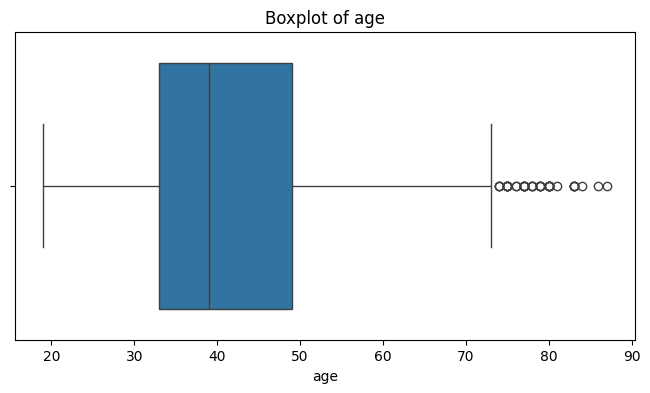

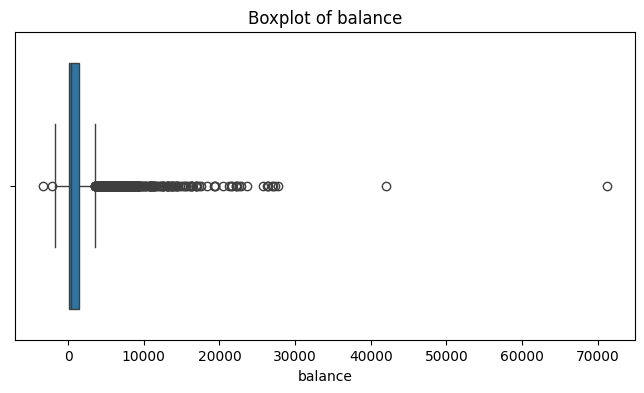

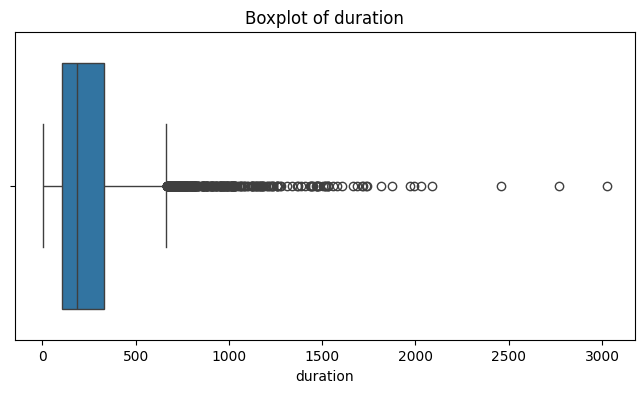

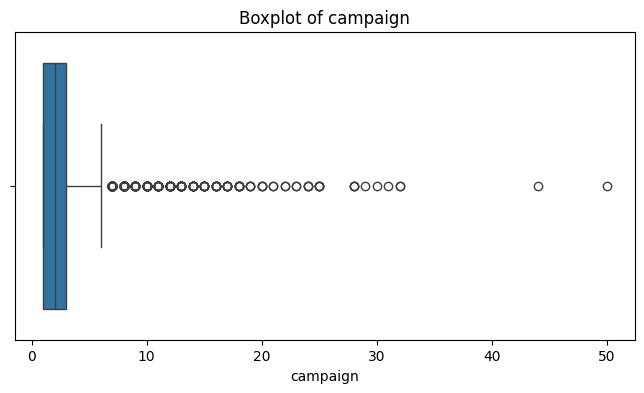

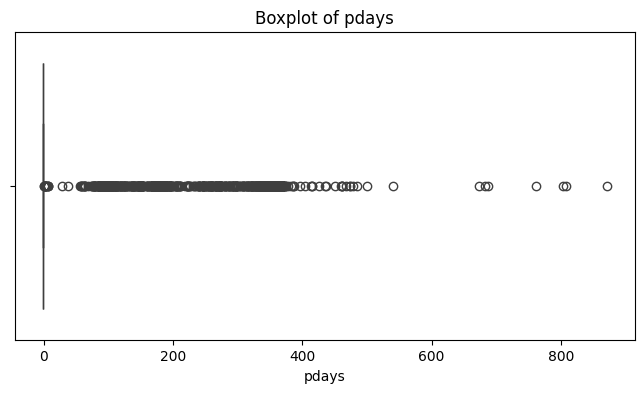

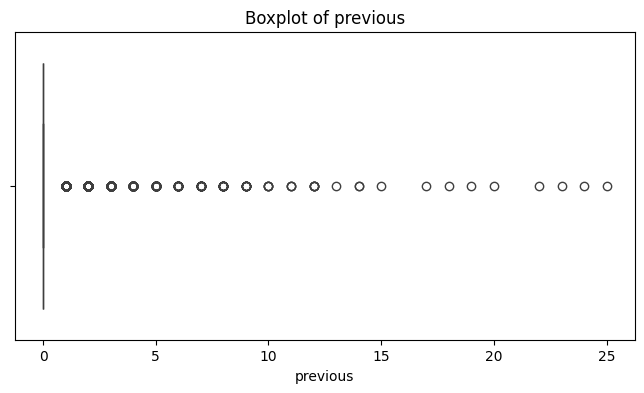

In [52]:
numeric_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [53]:
Q1 = df["balance"].quantile(0.25)
Q3 = df["balance"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["balance"] < lower) |
    (df["balance"] > upper)
]

len(outliers)

506

"Outliers were identified using the IQR method. Extreme values were reviewed for business validity and were retained where they represented legitimate observations."

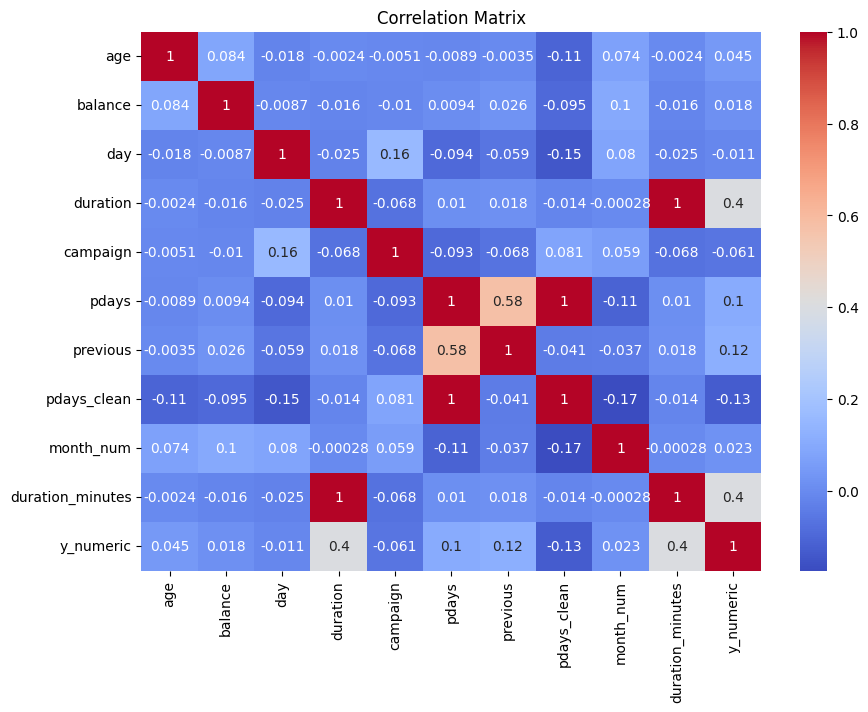

In [54]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [55]:
df.shape

(4521, 25)

In [61]:
df.isnull().sum()

age                     0
job                     0
marital                 0
education               0
default                 0
balance                 0
housing                 0
loan                    0
contact                 0
day                     0
month                   0
duration                0
campaign                0
pdays                   0
previous                0
poutcome                0
y                       0
previously_contacted    0
month_num               0
duration_minutes        0
age_group               0
balance_category        0
campaign_category       0
y_numeric               0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   4521 non-null   int64   
 1   job                   4521 non-null   str     
 2   marital               4521 non-null   str     
 3   education             4521 non-null   str     
 4   default               4521 non-null   str     
 5   balance               4521 non-null   int64   
 6   housing               4521 non-null   str     
 7   loan                  4521 non-null   str     
 8   contact               4521 non-null   str     
 9   day                   4521 non-null   int64   
 10  month                 4521 non-null   str     
 11  duration              4521 non-null   int64   
 12  campaign              4521 non-null   int64   
 13  pdays                 4521 non-null   int64   
 14  previous              4521 non-null   int64   
 15  poutcome       

In [64]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,previously_contacted,month_num,duration_minutes,age_group,balance_category,campaign_category,y_numeric
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,No,10,1.316667,26-35,Medium,1,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,Yes,5,3.666667,26-35,Medium,1,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,Yes,4,3.083333,26-35,Medium,1,0
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,No,6,3.316667,26-35,Medium,4-5,0
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,No,5,3.766667,56-65,Negative/Zero,1,0


#  EDA Visualizations

1. Subscription Distribution

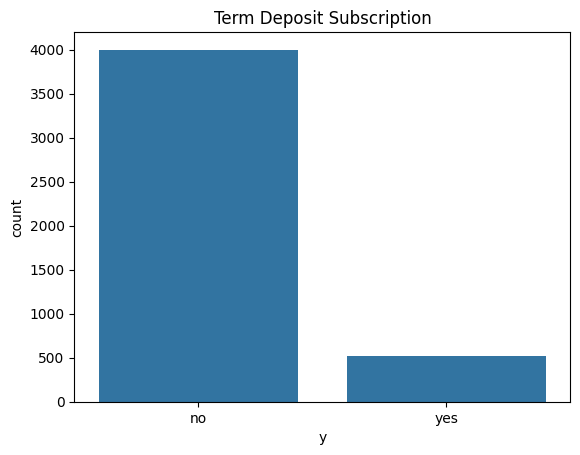

In [66]:
sns.countplot(data=df, x="y")
plt.title("Term Deposit Subscription")
plt.show()

2. Subscription By Job

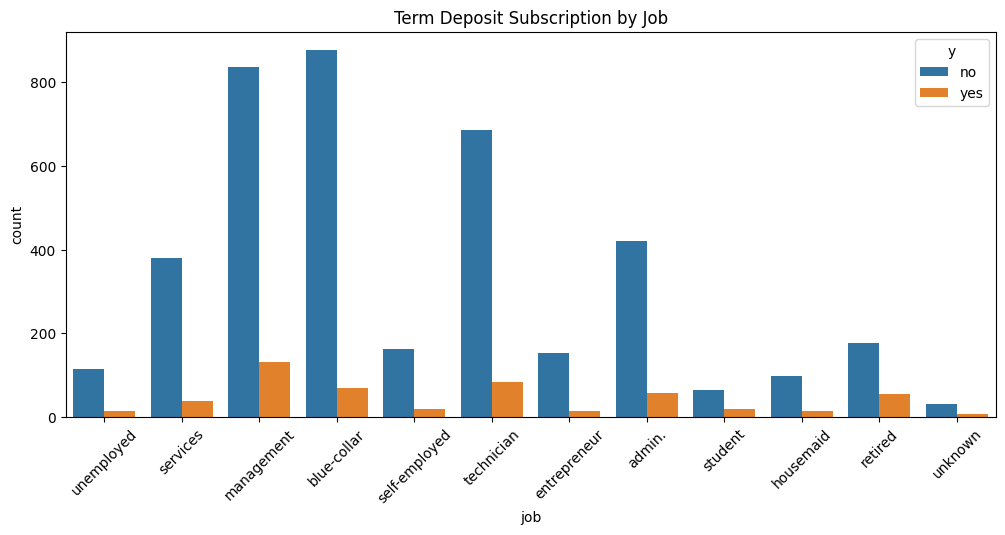

In [67]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="job",
    hue="y"
)

plt.xticks(rotation=45)
plt.title("Term Deposit Subscription by Job")
plt.show()

3. Subscripton by Education

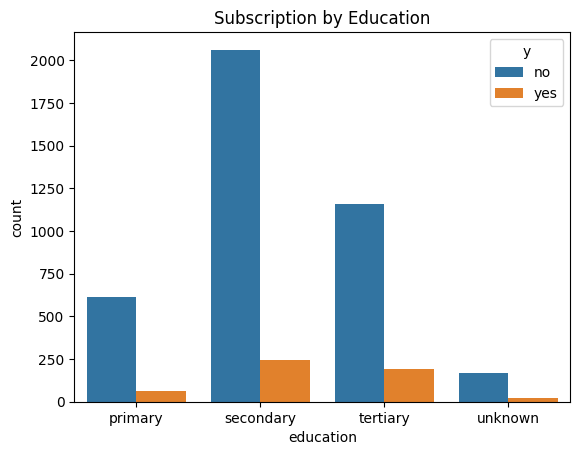

In [68]:
sns.countplot(
    data=df,
    x="education",
    hue="y"
)

plt.title("Subscription by Education")
plt.show()

4. Subscription by Housing Loan

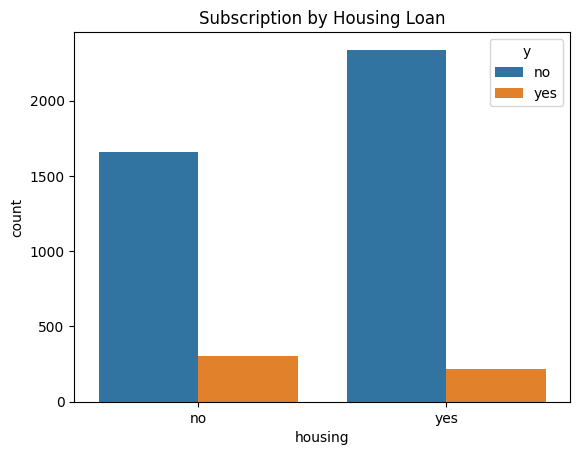

In [71]:
sns.countplot(
    data=df,
    x="housing",
    hue="y"
)

plt.title("Subscription by Housing Loan")
plt.show()

5. Subscription by Personal Loan

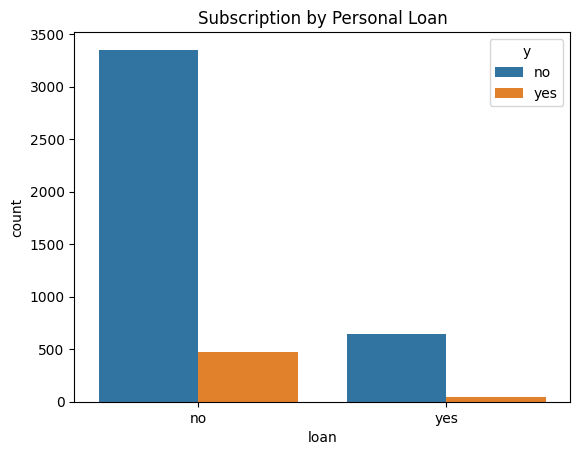

In [72]:
sns.countplot(
    data=df,
    x="loan",
    hue="y"
)

plt.title("Subscription by Personal Loan")
plt.show()

6. Subscription by Contact Type

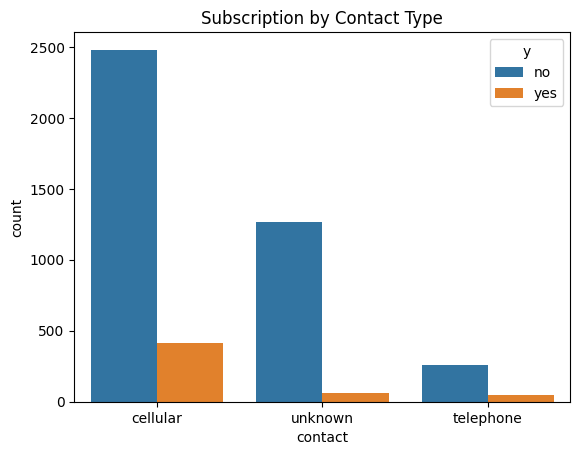

In [73]:
sns.countplot(
    data=df,
    x="contact",
    hue="y"
)

plt.title("Subscription by Contact Type")
plt.show()

7. Subscription by Month

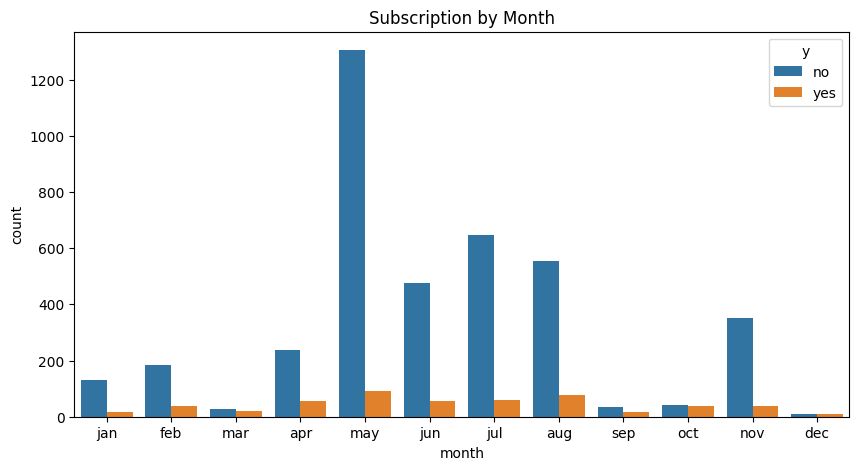

In [74]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="month",
    hue="y",
    order=month_map.keys()
)

plt.title("Subscription by Month")
plt.show()

8. Age Distribution

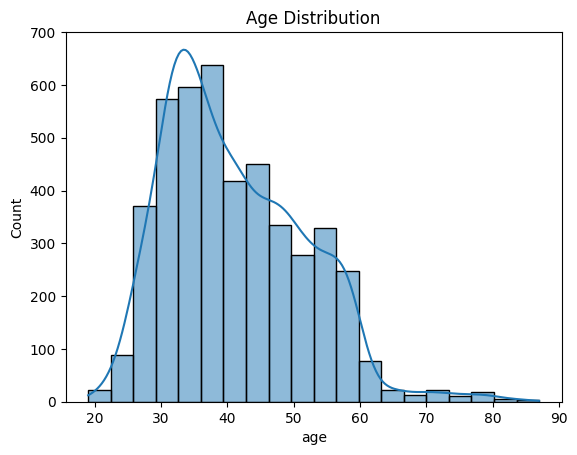

In [77]:
sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

9. Balance Distribution

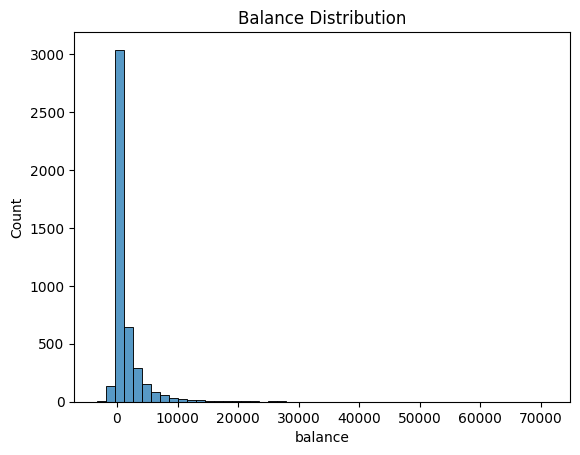

In [78]:
sns.histplot(
    data=df,
    x="balance",
    bins=50
)

plt.title("Balance Distribution")
plt.show()

10. Duration Vs Subscription

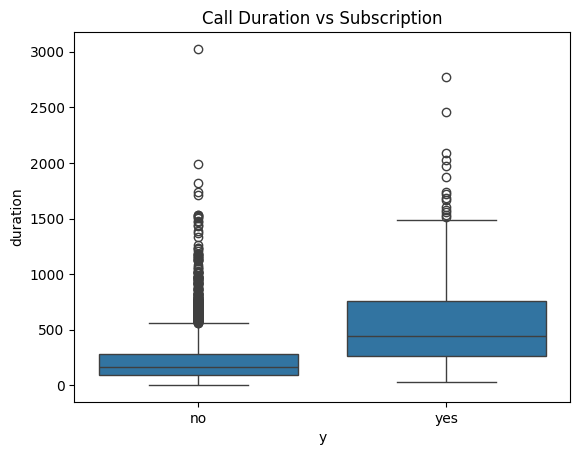

In [79]:
sns.boxplot(
    data=df,
    x="y",
    y="duration"
)

plt.title("Call Duration vs Subscription")
plt.show()

In [80]:
df.to_csv("bank_cleaned.csv", index=False)